# House Price Prediction (Regression)

## Introduction to Artificial Intelligence - Group 4 Assignment

### Group Members (Group 4)

1. Akliseya Shiferaw - DDU1600074  
2. Haymanot Assfa - RMD1261  
3. Sintayehu Begashaw - RMD2255  
4. Temen Alemayehu - DDU1600965  
5. Zekariyas Nigus - DDU1600782  
6. Ana Abdurezak - DDU1502265  
7. Natnael Haile - RMD1934  
8. Umer Jemal - DDU1600730

### Project Overview

**Problem type:** Regression (continuous value prediction)  
**Dataset:** California Housing Prices (local CSV)  
**Target:** `median_house_value` (house price)  
**Models:** Linear Regression, KNN Regressor, Decision Tree Regressor  
**Metrics:** MSE, MAE, R2  
**Plots:** Actual vs Predicted scatter, Residuals plots, and EDA visuals


In [16]:
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Plotting style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 1. Load the Dataset

Load the dataset from `housing.csv/housing.csv` into a pandas DataFrame.

In [17]:
DATA_PATH = "housing.csv/housing.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Explore the Dataset

Basic sanity checks and summaries (shape, schema, missing values, descriptive statistics).

In [18]:
# Shape
print("Shape:", df.shape)

# Info / dtypes / non-null counts
df.info()

# Missing values summary
missing_summary = (
    df.isna()
      .sum()
      .to_frame(name="missing_count")
      .assign(missing_pct=lambda s: (s["missing_count"] / len(df) * 100).round(2))
      .sort_values(["missing_count", "missing_pct"], ascending=False)
)
missing_summary

# Descriptive statistics
df.describe(include="all").T


Shape: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

Visualize distributions and relationships to better understand the data.

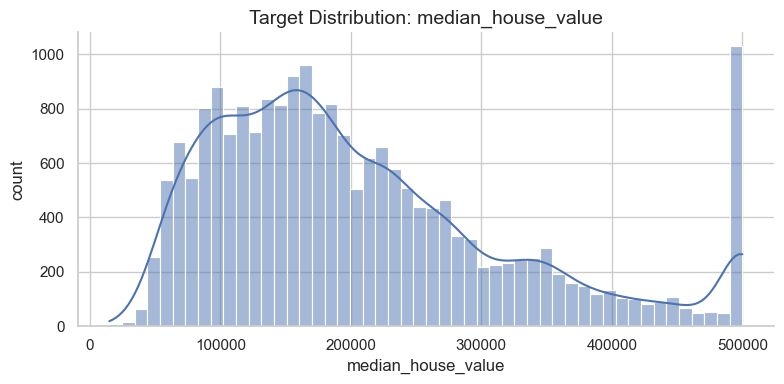

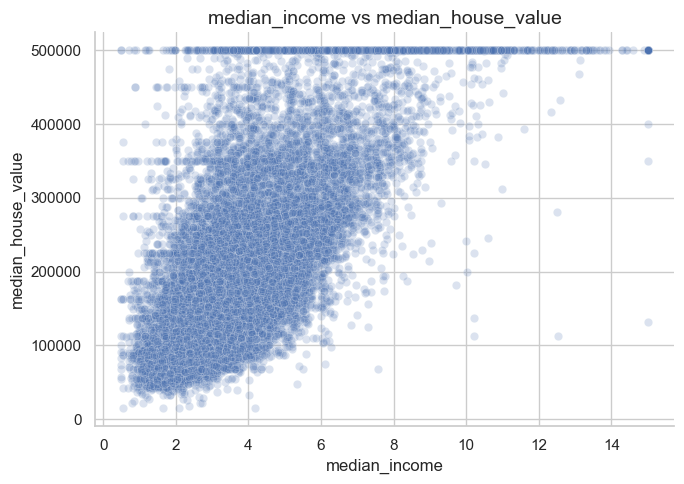

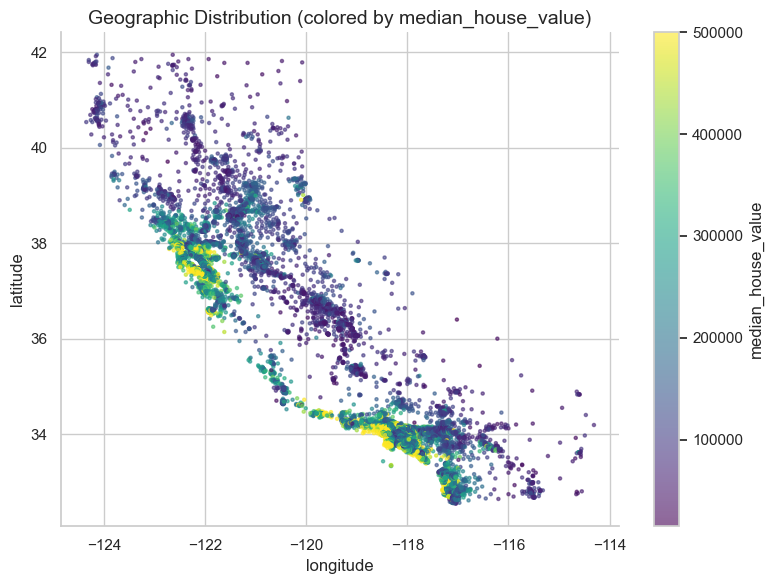

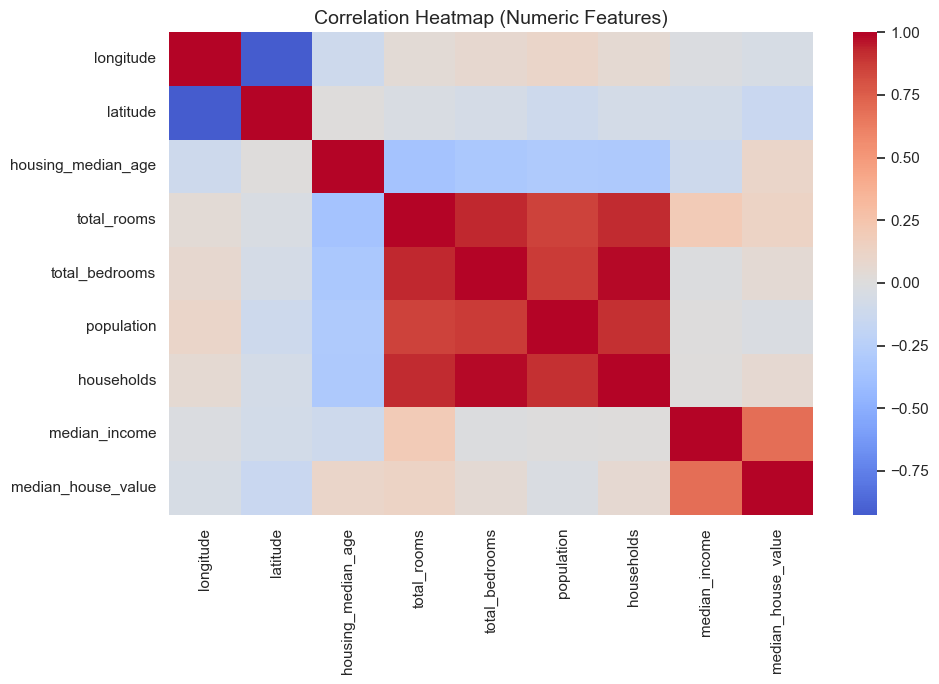

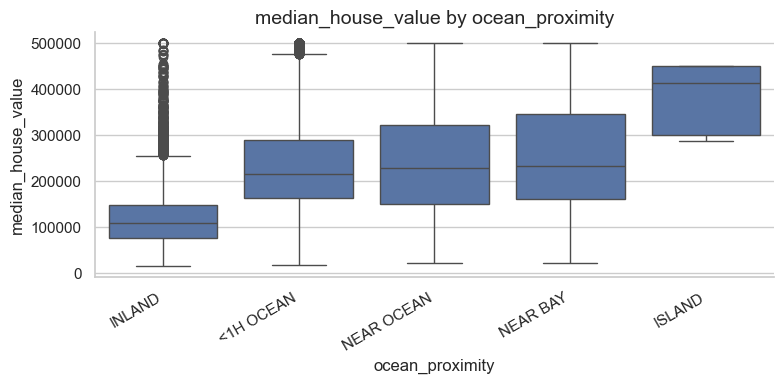

In [19]:
TARGET_COL = "median_house_value"

# EDA visuals

# Target distribution
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET_COL], bins=50, kde=True)
plt.title('Target Distribution: median_house_value')
plt.xlabel('median_house_value')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# Median income vs house value
plt.figure(figsize=(7, 5))
sns.scatterplot(x=df['median_income'], y=df[TARGET_COL], alpha=0.2)
plt.title('median_income vs median_house_value')
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.tight_layout()
plt.show()

# Geographic distribution colored by house value
plt.figure(figsize=(8, 6))
plt.scatter(df['longitude'], df['latitude'], c=df[TARGET_COL], cmap='viridis', s=5, alpha=0.6)
plt.colorbar(label='median_house_value')
plt.title('Geographic Distribution (colored by median_house_value)')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric only)
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

# Ocean proximity vs target (if present)
if 'ocean_proximity' in df.columns:
    plt.figure(figsize=(8, 4))
    order = df.groupby('ocean_proximity')[TARGET_COL].median().sort_values().index
    sns.boxplot(data=df, x='ocean_proximity', y=TARGET_COL, order=order)
    plt.xticks(rotation=30, ha='right')
    plt.title('median_house_value by ocean_proximity')
    plt.tight_layout()
    plt.show()


## 4. Dataset Splitting (70/15/15)

Define the target/features and create a 70/15/15 split using a two-stage `train_test_split` with `random_state=RANDOM_STATE`.

In [20]:
TARGET_COL = "median_house_value"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Stage 1: 70% train, 30% temporary (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

# Stage 2: split the 30% temporary into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print("Train size:", X_train.shape, y_train.shape)
print("Val size:  ", X_val.shape, y_val.shape)
print("Test size: ", X_test.shape, y_test.shape)


Train size: (14448, 9) (14448,)
Val size:   (3096, 9) (3096,)
Test size:  (3096, 9) (3096,)


## 5. Data Preprocessing (Pipeline + ColumnTransformer)

Identify numeric vs categorical columns, then define preprocessors for each model (scaled for KNN).

In [21]:
# Identify numeric vs categorical columns
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric columns ({len(numeric_features)}):", numeric_features)
print(f"Categorical columns ({len(categorical_features)}):", categorical_features)

# Common categorical pipeline: impute most frequent + one-hot encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Numeric pipelines
numeric_pipeline_no_scale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

numeric_pipeline_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# ColumnTransformers
preprocess_no_scale = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_no_scale, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_scaled, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

preprocess_no_scale, preprocess_scaled


Numeric columns (8): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical columns (1): ['ocean_proximity']


(ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median'))]),
                                  ['longitude', 'latitude', 'housing_median_age',
                                   'total_rooms', 'total_bedrooms', 'population',
                                   'households', 'median_income']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('onehot',
                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                  ['ocean_proximity'])]),
 ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(

## 6. Model Training (Train) and Model Selection (Validation)

We train three regression models:
- **Linear Regression**
- **KNN Regressor** (we select `k` using the validation set)
- **Decision Tree Regressor** (we select `max_depth` using the validation set)

We compare models using **MSE**, **MAE**, and **R2**.


In [22]:
def regression_metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

# 1) Linear Regression
lr_model = Pipeline(steps=[
    ("preprocess", preprocess_no_scale),
    ("model", LinearRegression()),
])

lr_model.fit(X_train, y_train)
y_val_pred_lr = lr_model.predict(X_val)
metrics_lr_val = regression_metrics(y_val, y_val_pred_lr)
metrics_lr_val


{'MSE': 5016590623.686, 'MAE': 51139.66933828897, 'R2': 0.6149282523650911}

In [23]:
# 2) Decision Tree Regressor (light tuning on max_depth)

tree_candidates = [None, 5, 10, 15, 20]

tree_results = []
for max_depth in tree_candidates:
    tree = Pipeline(steps=[
        ("preprocess", preprocess_no_scale),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=max_depth)),
    ])
    tree.fit(X_train, y_train)
    y_val_pred = tree.predict(X_val)
    m = regression_metrics(y_val, y_val_pred)
    tree_results.append({"max_depth": max_depth, **m})

tree_results_df = pd.DataFrame(tree_results).sort_values("MAE")
tree_results_df


,max_depth,MSE,MAE,R2
3,15.0,4.458534e+09,41782.297290,0.657764
2,10.0,4.086315e+09,42369.006895,0.686336
4,20.0,4.857397e+09,43773.745671,0.627148
0,NaN,4.865276e+09,44002.240310,0.626543
1,5.0,5.067283e+09,49903.782534,0.611037


In [24]:
# Select best tree model (lowest validation MAE)
_raw_depth = tree_results_df.iloc[0]["max_depth"]

# pandas may store this column as float; cast safely to int when not None
_best_tree_depth = None if pd.isna(_raw_depth) else (None if _raw_depth is None else int(_raw_depth))

tree_best_model = Pipeline(steps=[
    ("preprocess", preprocess_no_scale),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=_best_tree_depth)),
])

tree_best_model.fit(X_train, y_train)
_best_tree_depth


15

In [25]:
# 3) KNN Regressor (tune k on validation)

knn_candidates = [3, 5, 7, 9, 11, 15, 21]

knn_results = []
for k in knn_candidates:
    knn = Pipeline(steps=[
        ("preprocess", preprocess_scaled),
        ("model", KNeighborsRegressor(n_neighbors=int(k))),
    ])
    knn.fit(X_train, y_train)
    y_val_pred = knn.predict(X_val)
    m = regression_metrics(y_val, y_val_pred)
    knn_results.append({"k": int(k), **m})

knn_results_df = pd.DataFrame(knn_results).sort_values("MAE")
knn_results_df


,k,MSE,MAE,R2
2,7,3.870595e+09,41400.423911,0.702894
3,9,3.876289e+09,41513.712712,0.702457
4,11,3.860267e+09,41577.244979,0.703687
1,5,3.945697e+09,41675.995543,0.697130
5,15,3.852002e+09,41716.008721,0.704322
6,21,3.932373e+09,42440.130845,0.698152
0,3,4.264318e+09,43047.581718,0.672672


In [26]:
# Select best KNN model (lowest validation MAE)
_best_k = int(knn_results_df.iloc[0]["k"])

knn_best_model = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", KNeighborsRegressor(n_neighbors=_best_k)),
])

knn_best_model.fit(X_train, y_train)
_best_k


7

## 7. Final Evaluation (Test Set)

After selecting hyperparameters on the validation set (for KNN and Decision Tree), we evaluate each final model on the held-out test set.

In [27]:
# Evaluate on test set

y_test_pred_lr = lr_model.predict(X_test)
metrics_lr_test = regression_metrics(y_test, y_test_pred_lr)

# Decision Tree
y_test_pred_tree = tree_best_model.predict(X_test)
metrics_tree_test = regression_metrics(y_test, y_test_pred_tree)

# KNN
y_test_pred_knn = knn_best_model.predict(X_test)
metrics_knn_test = regression_metrics(y_test, y_test_pred_knn)

comparison = (
    pd.DataFrame([
        {"Model": "Linear Regression", **metrics_lr_test},
        {"Model": f"Decision Tree (max_depth={_best_tree_depth})", **metrics_tree_test},
        {"Model": f"KNN (k={_best_k})", **metrics_knn_test},
    ])
    .set_index("Model")
    .sort_values("MAE")
)

comparison


,MSE,MAE,R2
Model,,,
KNN (k=7),3.548887e+09,40337.914544,0.731615
Decision Tree (max_depth=15),4.266959e+09,41197.098411,0.677310
Linear Regression,4.450206e+09,49016.596640,0.663452


### ?? Metrics Comparison (Test Set)

Bar charts to visually compare model performance.

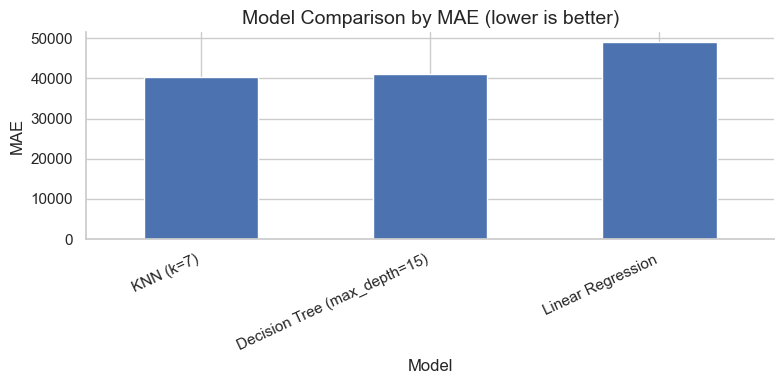

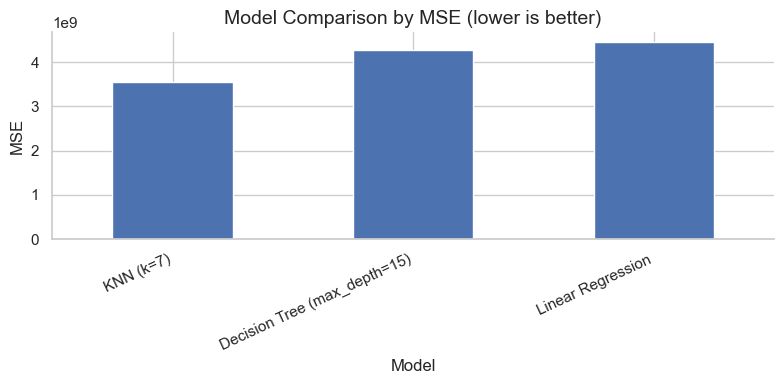

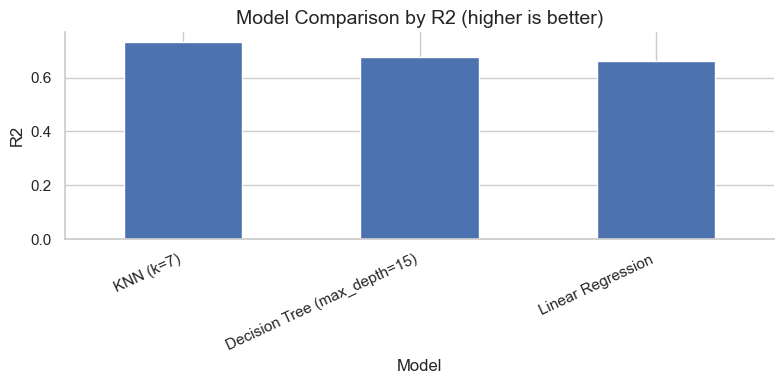

In [28]:
# Plot metric comparison

metric_to_plot = 'MAE'
plt.figure(figsize=(8, 4))
comparison_sorted = comparison.sort_values(metric_to_plot)
comparison_sorted[metric_to_plot].plot(kind='bar')
plt.title(f'Model Comparison by {metric_to_plot} (lower is better)')
plt.ylabel(metric_to_plot)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

for metric_to_plot in ['MSE', 'R2']:
    plt.figure(figsize=(8, 4))
    comparison_sorted = comparison.sort_values(metric_to_plot, ascending=(metric_to_plot != 'R2'))
    comparison_sorted[metric_to_plot].plot(kind='bar')
    direction = 'lower is better' if metric_to_plot == 'MSE' else 'higher is better'
    plt.title(f'Model Comparison by {metric_to_plot} ({direction})')
    plt.ylabel(metric_to_plot)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()


## 8A. Additional Presentation Graphics

The following visualizations enhance presentation quality and help interpret results:
- Feature distributions (numeric)
- KNN tuning curve (Validation R2 vs k)
- Decision Tree feature importance
- Bias-variance style check (Train vs Test R2)
- Actual vs Predicted across Train/Val/Test
- Residual distributions per model


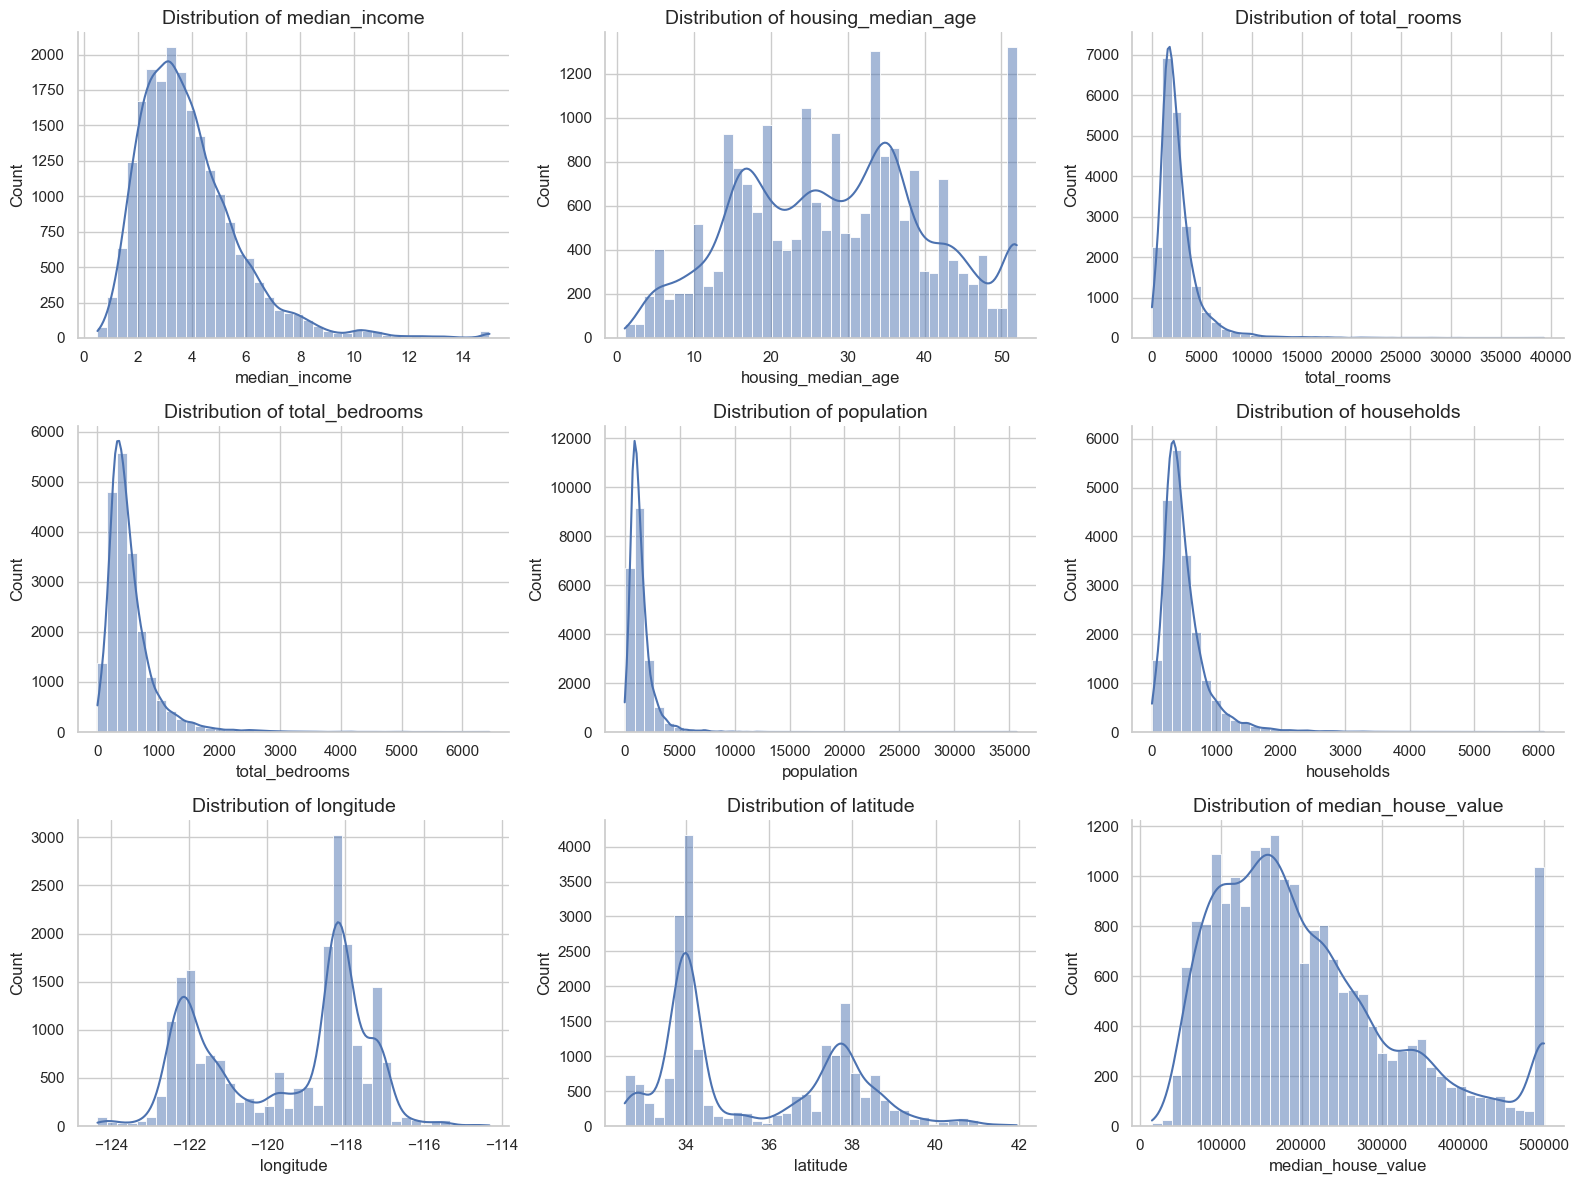

In [29]:
# Feature distributions (numeric)

num_cols = df.select_dtypes(include=['number']).columns.tolist()
# Keep a focused set if too many
preferred = [
    'median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms',
    'population', 'households', 'longitude', 'latitude', TARGET_COL
]
plot_cols = [c for c in preferred if c in df.columns]
if len(plot_cols) == 0:
    plot_cols = num_cols[:9]

n = len(plot_cols)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(16, 4*rows))
for idx, col in enumerate(plot_cols, 1):
    ax = plt.subplot(rows, cols, idx)
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


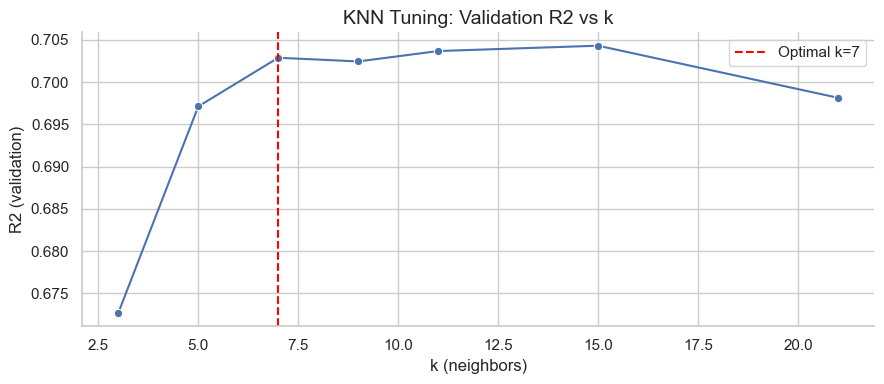

In [30]:
# KNN tuning curve (Validation set)

if 'knn_results_df' in globals():
    tmp = knn_results_df.sort_values('k')
    plt.figure(figsize=(9, 4))
    sns.lineplot(data=tmp, x='k', y='R2', marker='o')
    plt.axvline(_best_k, color='red', linestyle='--', label=f'Optimal k={_best_k}')
    plt.title('KNN Tuning: Validation R2 vs k')
    plt.xlabel('k (neighbors)')
    plt.ylabel('R2 (validation)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('knn_results_df not found; skipping plot')


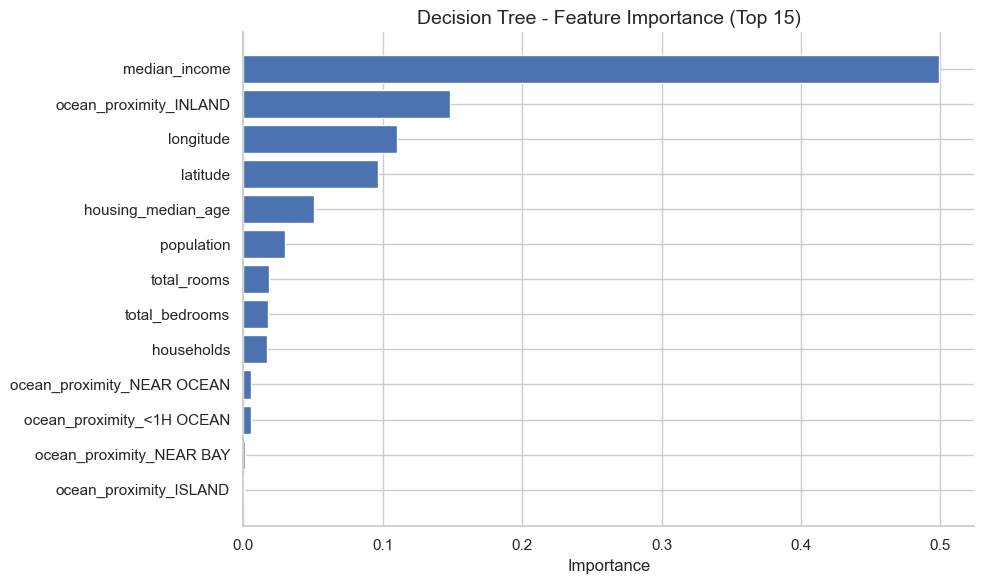

In [31]:
# Decision Tree feature importance (Top 15)

def get_feature_names_from_column_transformer(ct):
    feature_names = []
    for name, trans, cols in ct.transformers_:
        if name == 'remainder' and trans == 'drop':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            try:
                # For pipelines, the last step usually implements get_feature_names_out
                feature_names.extend(trans.get_feature_names_out(cols))
            except TypeError:
                feature_names.extend(trans.get_feature_names_out())
        else:
            # passthrough or simple transformers
            if isinstance(cols, (list, tuple)):
                feature_names.extend(cols)
            else:
                feature_names.append(cols)
    return feature_names

# Extract the trained tree estimator and preprocessor
_tree_est = tree_best_model.named_steps['model']
_pre = tree_best_model.named_steps['preprocess']

try:
    feat_names = get_feature_names_from_column_transformer(_pre)
except Exception as e:
    feat_names = None
    print('Could not extract feature names:', e)

importances = _tree_est.feature_importances_

if feat_names is None or len(feat_names) != len(importances):
    feat_names = [f'feature_{i}' for i in range(len(importances))]

fi = (
    pd.DataFrame({'feature': feat_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
    .sort_values('importance')
)

plt.figure(figsize=(10, 6))
plt.barh(fi['feature'], fi['importance'])
plt.title('Decision Tree - Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


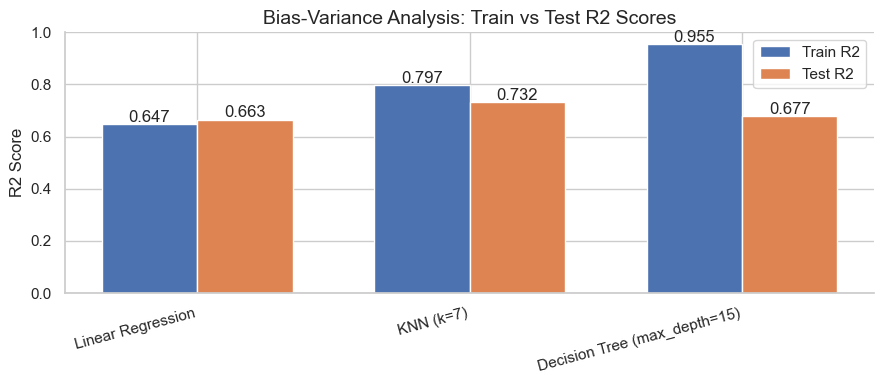

,Model,Train_R2,Test_R2
0,Linear Regression,0.647048,0.663452
1,KNN (k=7),0.796794,0.731615
2,Decision Tree (max_depth=15),0.954722,0.677310


In [32]:
# Bias-Variance style check: Train vs Test R2

def r2_on_split(model, X_split, y_split):
    return r2_score(y_split, model.predict(X_split))

models_for_bv = {
    'Linear Regression': lr_model,
    f'KNN (k={_best_k})': knn_best_model,
    f'Decision Tree (max_depth={_best_tree_depth})': tree_best_model,
}

bv_rows = []
for name, model in models_for_bv.items():
    bv_rows.append({
        'Model': name,
        'Train_R2': r2_on_split(model, X_train, y_train),
        'Test_R2': r2_on_split(model, X_test, y_test),
    })

bv_df = pd.DataFrame(bv_rows)

plt.figure(figsize=(9, 4))
x = np.arange(len(bv_df))
width = 0.35
plt.bar(x - width/2, bv_df['Train_R2'], width, label='Train R2')
plt.bar(x + width/2, bv_df['Test_R2'], width, label='Test R2')
plt.xticks(x, bv_df['Model'], rotation=15, ha='right')
for i in range(len(bv_df)):
    plt.text(i - width/2, bv_df['Train_R2'].iloc[i] + 0.01, f"{bv_df['Train_R2'].iloc[i]:.3f}", ha='center')
    plt.text(i + width/2, bv_df['Test_R2'].iloc[i] + 0.01, f"{bv_df['Test_R2'].iloc[i]:.3f}", ha='center')
plt.ylim(0, 1.0)
plt.ylabel('R2 Score')
plt.title('Bias-Variance Analysis: Train vs Test R2 Scores')
plt.legend()
plt.tight_layout()
plt.show()

bv_df


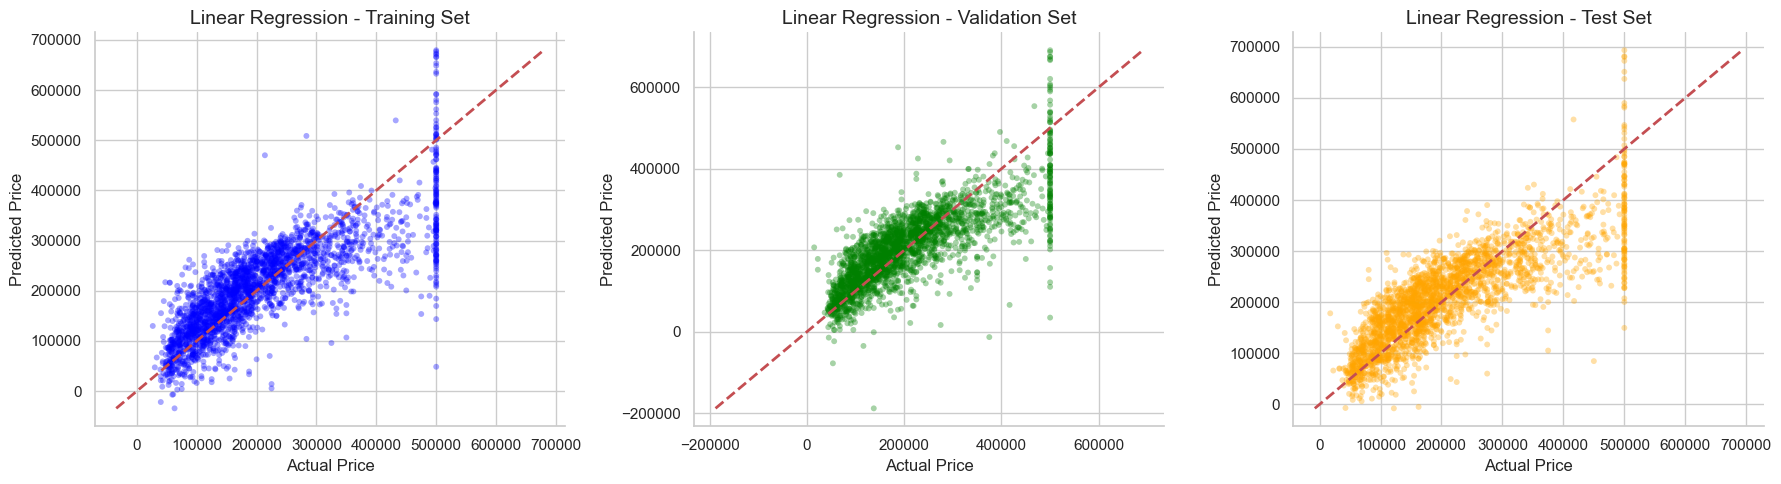

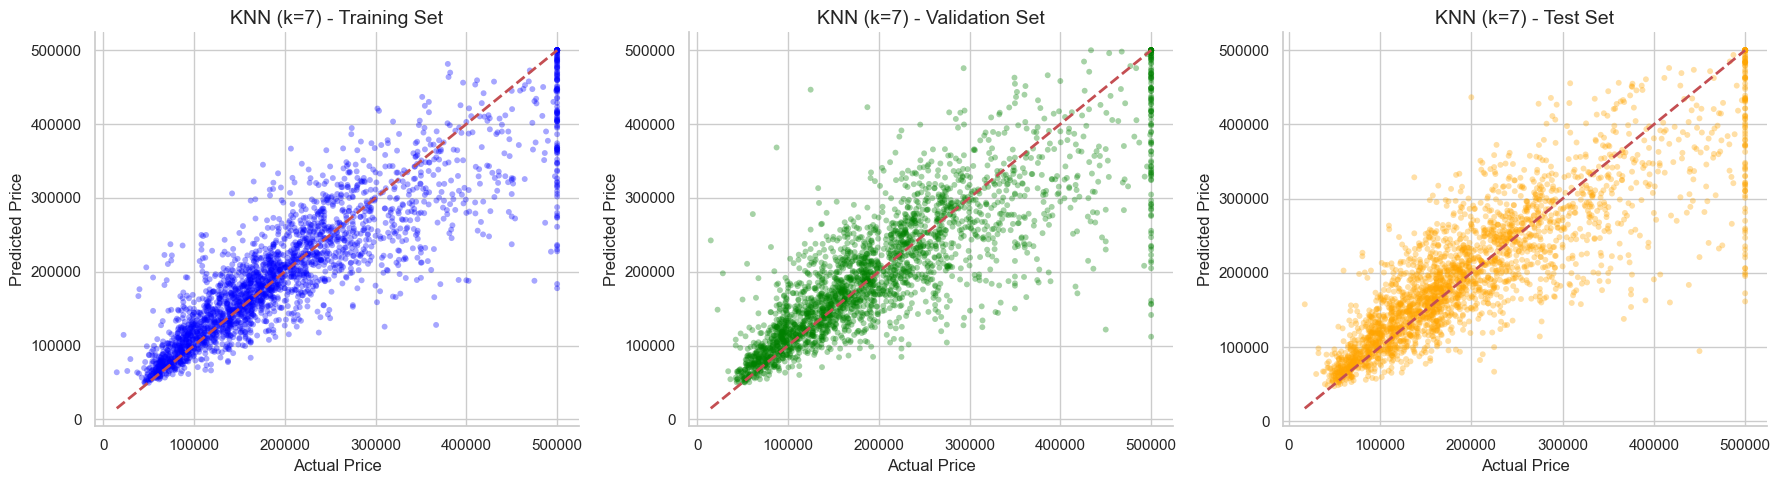

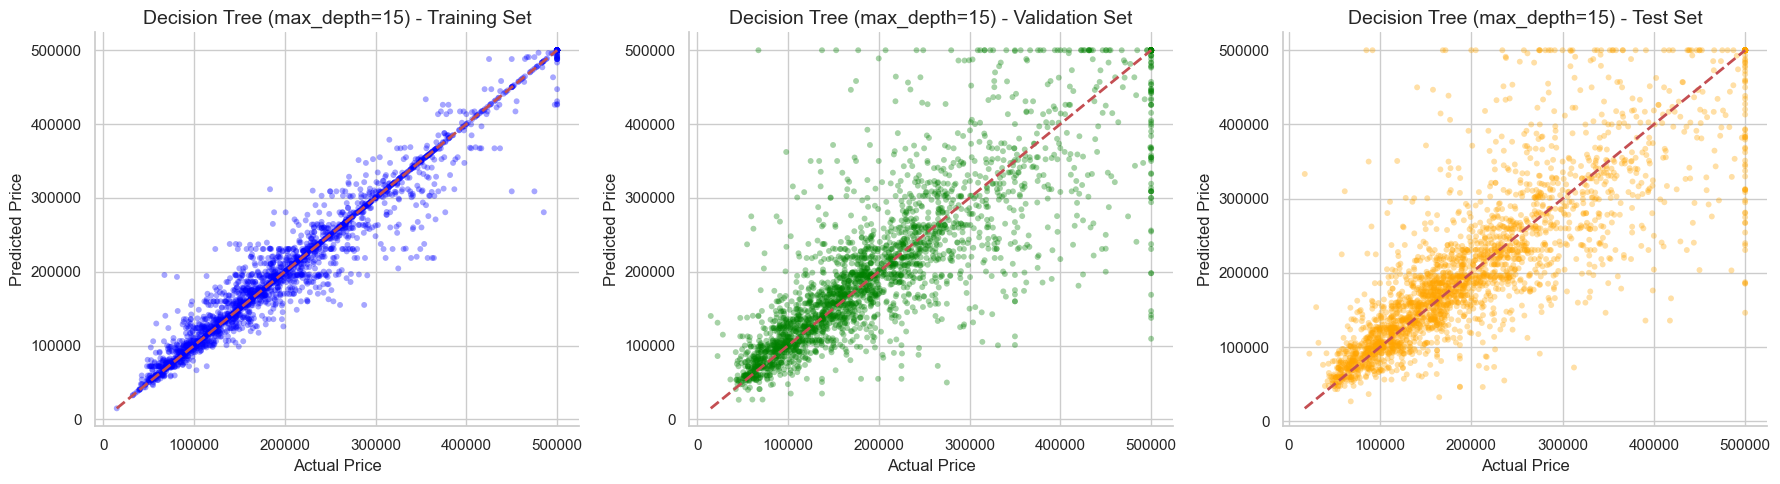

In [33]:
# Actual vs Predicted across Train / Validation / Test (per model)

def plot_actual_pred_splits(model, model_name, max_points=2500):
    splits = [
        ('Training Set', X_train, y_train, 'blue'),
        ('Validation Set', X_val, y_val, 'green'),
        ('Test Set', X_test, y_test, 'orange'),
    ]

    plt.figure(figsize=(18, 5))
    for i, (title, Xs, ys, color) in enumerate(splits, 1):
        yp = model.predict(Xs)
        # sample for plotting
        if len(ys) > max_points:
            idx = np.random.choice(len(ys), size=max_points, replace=False)
            ys_s = ys.iloc[idx]
            yp_s = yp[idx]
        else:
            ys_s = ys
            yp_s = yp

        ax = plt.subplot(1, 3, i)
        ax.scatter(ys_s, yp_s, alpha=0.35, s=18, c=color, edgecolors='none')
        min_v = min(ys_s.min(), np.min(yp_s))
        max_v = max(ys_s.max(), np.max(yp_s))
        ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2)
        ax.set_title(f'{model_name} - {title}')
        ax.set_xlabel('Actual Price')
        ax.set_ylabel('Predicted Price')

    plt.tight_layout()
    plt.show()

plot_actual_pred_splits(lr_model, 'Linear Regression')
plot_actual_pred_splits(knn_best_model, f'KNN (k={_best_k})')
plot_actual_pred_splits(tree_best_model, f'Decision Tree (max_depth={_best_tree_depth})')


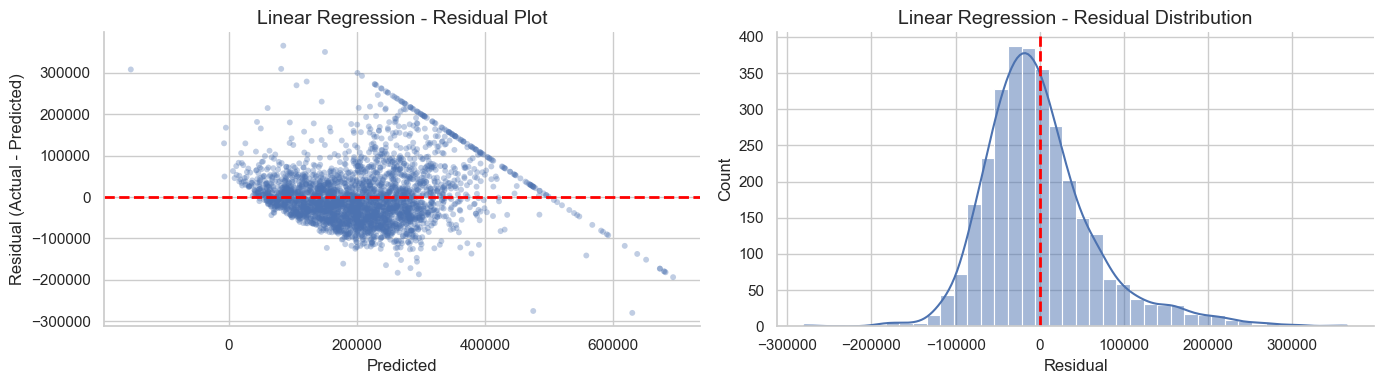

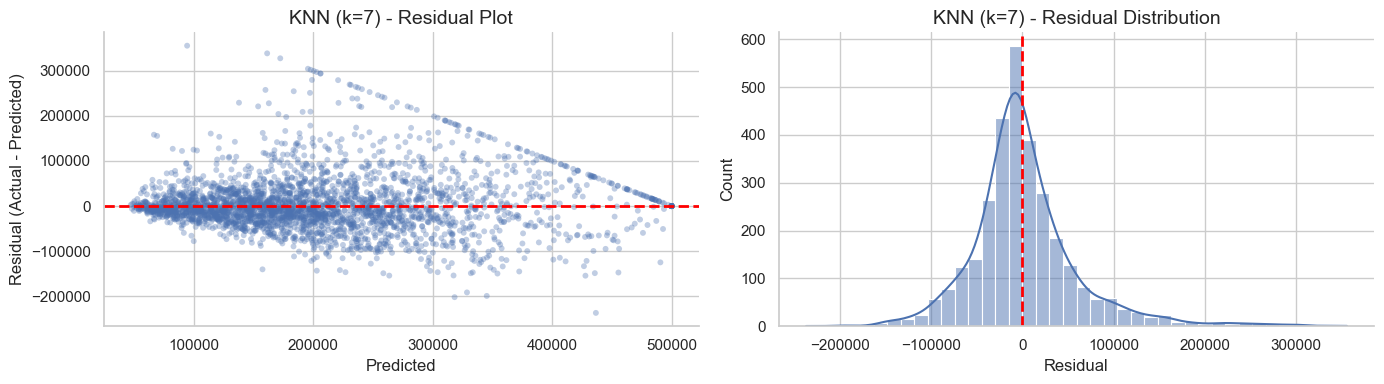

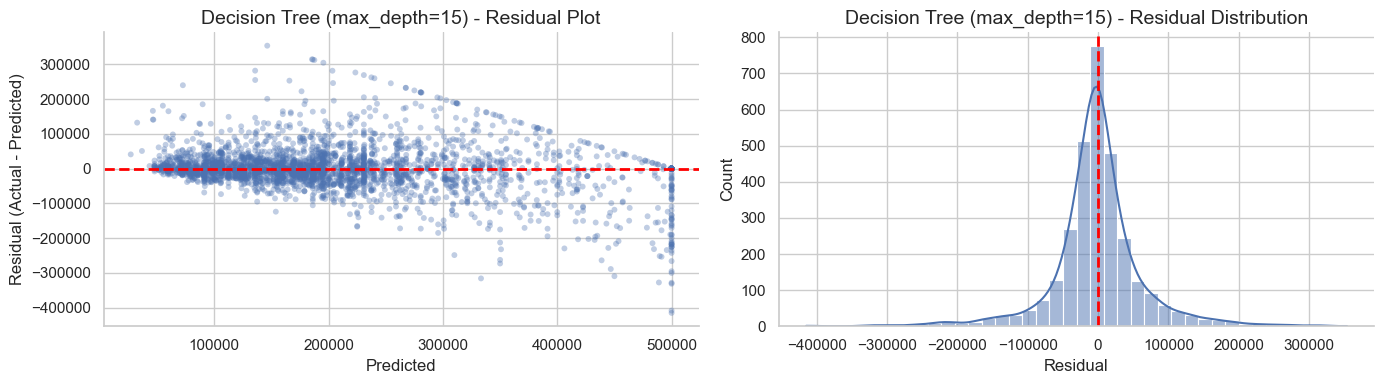

In [34]:
# Residual plots + residual distributions (per model)

def plot_residuals_with_distribution(y_true, y_pred, title, max_points=3000):
    residuals = y_true - y_pred

    # sample for scatter
    if len(y_true) > max_points:
        idx = np.random.choice(len(y_true), size=max_points, replace=False)
        y_true_s = y_true.iloc[idx]
        y_pred_s = y_pred[idx]
        residuals_s = y_true_s - y_pred_s
    else:
        y_pred_s = y_pred
        residuals_s = residuals

    plt.figure(figsize=(14, 4))

    ax1 = plt.subplot(1, 2, 1)
    ax1.scatter(y_pred_s, residuals_s, alpha=0.35, s=18, edgecolors='none')
    ax1.axhline(0, color='red', linestyle='--', linewidth=2)
    ax1.set_title(f'{title} - Residual Plot')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Residual (Actual - Predicted)')

    ax2 = plt.subplot(1, 2, 2)
    sns.histplot(residuals, bins=40, kde=True, ax=ax2)
    ax2.axvline(0, color='red', linestyle='--', linewidth=2)
    ax2.set_title(f'{title} - Residual Distribution')
    ax2.set_xlabel('Residual')

    plt.tight_layout()
    plt.show()

plot_residuals_with_distribution(y_test, y_test_pred_lr, 'Linear Regression')
plot_residuals_with_distribution(y_test, y_test_pred_knn, f'KNN (k={_best_k})')
plot_residuals_with_distribution(y_test, y_test_pred_tree, f'Decision Tree (max_depth={_best_tree_depth})')


## 8. Actual vs Predicted and Residual Analysis

For regression, we use scatter plots (Actual vs Predicted) and residual plots to assess performance.

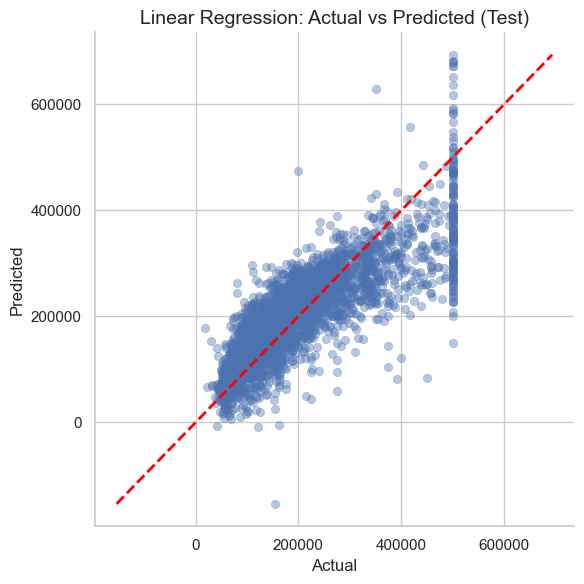

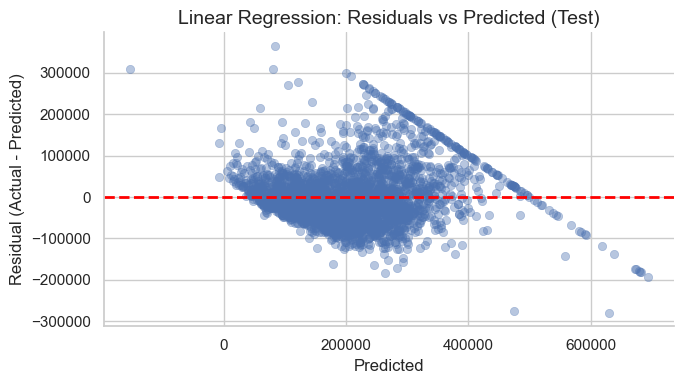

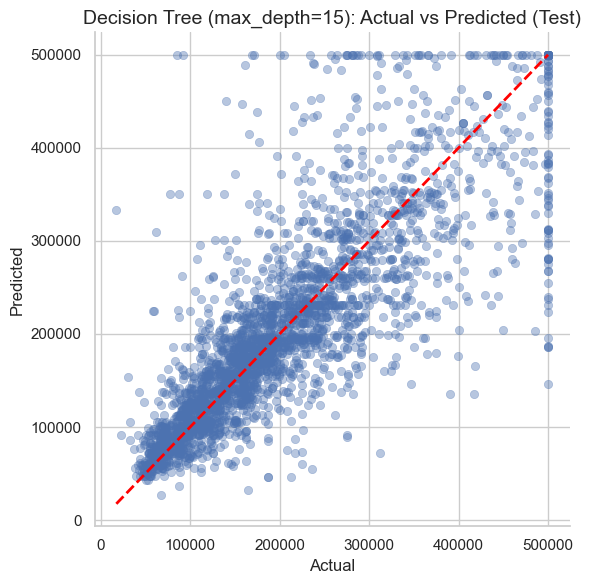

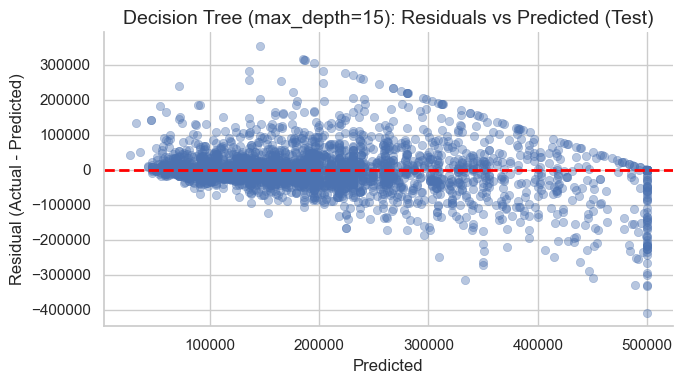

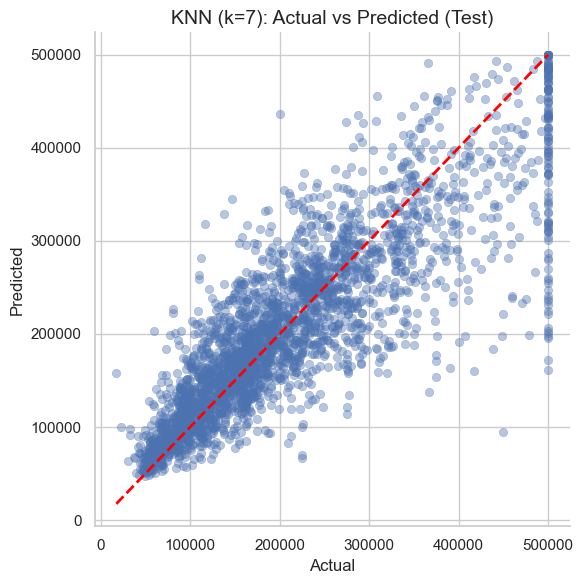

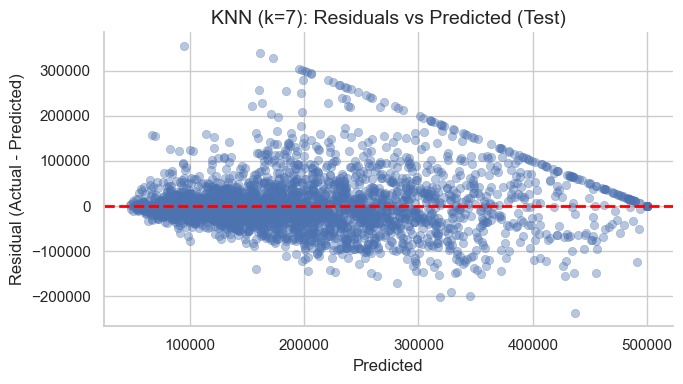

In [35]:
def _maybe_sample(y_true, y_pred, max_points=3000):
    # Sampling only affects plots (metrics are computed on full test set).
    n = len(y_true)
    if n <= max_points:
        return y_true, y_pred
    idx = np.random.choice(n, size=max_points, replace=False)
    return y_true.iloc[idx], y_pred[idx]

def plot_actual_vs_predicted(y_true, y_pred, title):
    y_true_s, y_pred_s = _maybe_sample(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_true_s, y=y_pred_s, alpha=0.4, edgecolor=None)
    min_v = min(y_true_s.min(), np.min(y_pred_s))
    max_v = max(y_true_s.max(), np.max(y_pred_s))
    plt.plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--", linewidth=2)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    y_true_s, y_pred_s = _maybe_sample(y_true, y_pred)
    residuals_s = y_true_s - y_pred_s

    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=y_pred_s, y=residuals_s, alpha=0.4, edgecolor=None)
    plt.axhline(0, color="red", linestyle="--", linewidth=2)
    plt.xlabel("Predicted")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plots per model (test set)
plot_actual_vs_predicted(y_test, y_test_pred_lr, "Linear Regression: Actual vs Predicted (Test)")
plot_residuals(y_test, y_test_pred_lr, "Linear Regression: Residuals vs Predicted (Test)")

plot_actual_vs_predicted(y_test, y_test_pred_tree, f"Decision Tree (max_depth={_best_tree_depth}): Actual vs Predicted (Test)")
plot_residuals(y_test, y_test_pred_tree, f"Decision Tree (max_depth={_best_tree_depth}): Residuals vs Predicted (Test)")

plot_actual_vs_predicted(y_test, y_test_pred_knn, f"KNN (k={_best_k}): Actual vs Predicted (Test)")
plot_residuals(y_test, y_test_pred_knn, f"KNN (k={_best_k}): Residuals vs Predicted (Test)")


## 9. Conclusion

Summary of results and best-performing model.

### Detailed Conclusion (Programmatic Summary)

In [36]:
# Detailed conclusion report (inspired by the sample format)

print()
print("="*70)
print("FINAL ANALYSIS AND CONCLUSIONS")
print("="*70)

# Build a convenient dict-like structure from the comparison table
# Note: `comparison` is indexed by Model and contains MSE/MAE/R2 computed on the TEST set.
test_results = comparison.to_dict(orient="index")
trained_models = {name: None for name in test_results.keys()}  # placeholder to match sample structure

print()
print("1. MODEL PERFORMANCE RANKING (by Test R2 Score):")
print("-" * 70)
sorted_models = sorted(trained_models.keys(), key=lambda x: test_results[x]["R2"], reverse=True)

for rank, model_name in enumerate(sorted_models, 1):
    print(f"   {rank}. {model_name}")
    print(f"      - R2 Score: {test_results[model_name]['R2']:.6f}")
    print(f"      - MAE: ${test_results[model_name]['MAE']:.2f}")
    print(f"      - MSE: {test_results[model_name]['MSE']:.3e}")

print()
print("2. KEY INSIGHTS:")
print("-" * 70)
best_model = sorted_models[0]
worst_model = sorted_models[-1]

best_r2 = test_results[best_model]["R2"]
worst_r2 = test_results[worst_model]["R2"]

print(f"   Best Model: {best_model}")
print(f"   Explains {best_r2*100:.2f}% of variance in house prices")

print()
print(f"   Worst Model: {worst_model}")
print(f"   Explains {worst_r2*100:.2f}% of variance in house prices")

print()
print(f"   Performance Gap: {(best_r2 - worst_r2)*100:.2f}% difference in R2 scores")

print()
print("3. RECOMMENDATIONS:")
print("-" * 70)
if best_r2 > 0.7:
    print(f"   STRONG: {best_model} shows strong predictive power")
    print("   and can be reliably used for house price predictions.")
elif best_r2 > 0.5:
    print(f"   MODERATE: {best_model} shows moderate predictive power.")
    print("   Consider additional feature engineering or ensemble methods.")
else:
    print("   LIMITED: Current models show limited predictive power.")
    print("   Consider exploring additional features or more advanced models.")

print("="*70)



FINAL ANALYSIS AND CONCLUSIONS

1. MODEL PERFORMANCE RANKING (by Test R2 Score):
----------------------------------------------------------------------
   1. KNN (k=7)
      - R2 Score: 0.731615
      - MAE: $40337.91
      - MSE: 3.549e+09
   2. Decision Tree (max_depth=15)
      - R2 Score: 0.677310
      - MAE: $41197.10
      - MSE: 4.267e+09
   3. Linear Regression
      - R2 Score: 0.663452
      - MAE: $49016.60
      - MSE: 4.450e+09

2. KEY INSIGHTS:
----------------------------------------------------------------------
   Best Model: KNN (k=7)
   Explains 73.16% of variance in house prices

   Worst Model: Linear Regression
   Explains 66.35% of variance in house prices

   Performance Gap: 6.82% difference in R2 scores

3. RECOMMENDATIONS:
----------------------------------------------------------------------
   STRONG: KNN (k=7) shows strong predictive power
   and can be reliably used for house price predictions.


In [37]:
best_model_name = comparison.index[0]
print("Best model on Test (lowest MAE):", best_model_name)
comparison


Best model on Test (lowest MAE): KNN (k=7)


,MSE,MAE,R2
Model,,,
KNN (k=7),3.548887e+09,40337.914544,0.731615
Decision Tree (max_depth=15),4.266959e+09,41197.098411,0.677310
Linear Regression,4.450206e+09,49016.596640,0.663452
